# Modélisation

## Importation et demarrage spark

In [40]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, count, when, percentile_approx
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline

sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = ['#3498db', '#e74c3c']

spark = (
    SparkSession.builder
    .appName('04_modelisation_immobilier')
    .master('local[*]')
    .config('spark.ui.enabled', 'false')
    .config('spark.sql.shuffle.partitions', '8')
    .getOrCreate()
)

spark.sparkContext.setLogLevel('ERROR')
print('Spark démarré, version:', spark.version)

Spark démarré, version: 4.1.1


In [41]:
##  1. Chargement des données

In [42]:
df = spark.read.parquet('../data/clean')

In [43]:
df.count()

5336

## Analyse exploratoire - Variable surface

In [44]:
df.select('surface').summary().show()

+-------+-----------------+
|summary|          surface|
+-------+-----------------+
|  count|             5336|
|   mean|81.92859820089954|
| stddev|55.84448515472042|
|    min|              5.0|
|    25%|             47.0|
|    50%|             70.0|
|    75%|            101.0|
|    max|           1233.0|
+-------+-----------------+



In [45]:
# Skewness et kurtosis
stats_surface = df.select(
    F.skewness('surface').alias('skewness'),
    F.kurtosis('surface').alias('kurtosis')
).collect()[0]

print(f"Skewness (asymétrie) : {stats_surface['skewness']:.4f}")
print(f"Kurtosis (aplatissement) : {stats_surface['kurtosis']:.4f}")

Skewness (asymétrie) : 3.9755
Kurtosis (aplatissement) : 47.5261


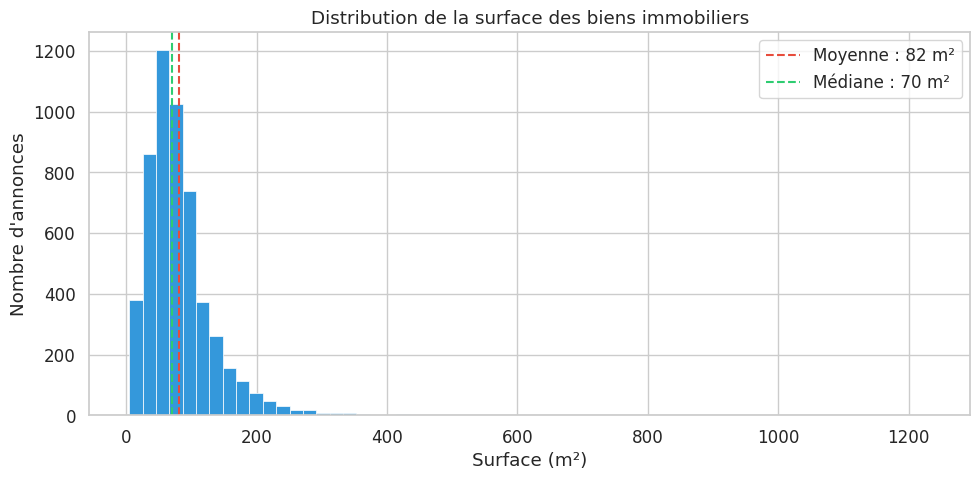

In [46]:
surface_pd = df.select('surface').dropna().toPandas()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(surface_pd['surface'], bins=60, color='#3498db', edgecolor='white', linewidth=0.5)

mean_val   = surface_pd['surface'].mean()
median_val = surface_pd['surface'].median()

ax.axvline(mean_val,   color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Moyenne : {mean_val:.0f} m²')
ax.axvline(median_val, color='#2ecc71', linestyle='--', linewidth=1.5, label=f'Médiane : {median_val:.0f} m²')

ax.set_xlabel('Surface (m²)')
ax.set_ylabel('Nombre d\'annonces')
ax.set_title('Distribution de la surface des biens immobiliers')
ax.legend()
plt.tight_layout()
plt.show()

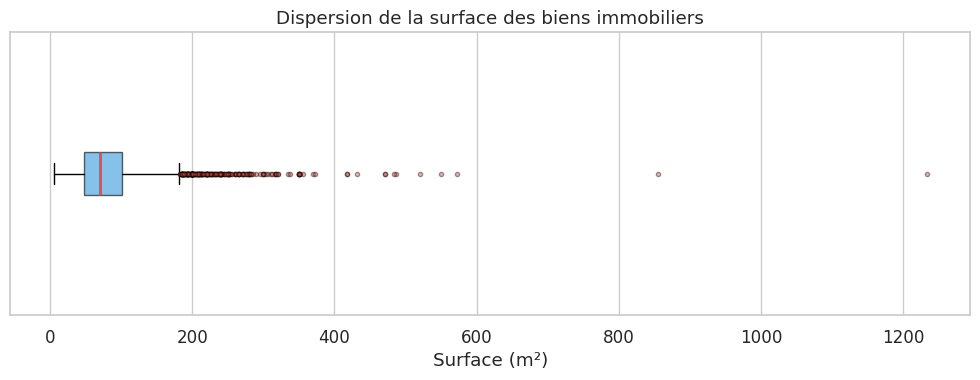

In [47]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot(surface_pd['surface'].dropna(), vert=False, patch_artist=True,
           boxprops=dict(facecolor='#3498db', alpha=0.6),
           medianprops=dict(color='#e74c3c', linewidth=2),
           flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=3, alpha=0.4))

ax.set_xlabel('Surface (m²)')
ax.set_title('Dispersion de la surface des biens immobiliers')
ax.yaxis.set_visible(False)
plt.tight_layout()
plt.show()

- On voit que la plupart des biens sont dans la zone 47m² à 101m², nous avons quelques biens très grandes qui tirent la moyenne vers la haut, cela montre que la distribution n'est pas symetrique on a un etalement vers la droite. 
- Le minimum parait bizzare 5m2 avec le type de bien qu'on à. nous allons verifier et supprimer si c'est incoherent. 

In [48]:
df.select('surface', 'type_bien', 'prix').orderBy('surface').show(30, truncate=False)

+-------+-----------+--------+
|surface|type_bien  |prix    |
+-------+-----------+--------+
|5.0    |appartement|47000.0 |
|7.0    |appartement|100000.0|
|7.0    |appartement|70000.0 |
|7.0    |appartement|69500.0 |
|7.0    |appartement|55000.0 |
|8.0    |studio     |80000.0 |
|8.0    |studio     |133000.0|
|8.0    |appartement|109900.0|
|8.0    |appartement|89900.0 |
|8.0    |studio     |222000.0|
|8.0    |appartement|94000.0 |
|9.0    |appartement|53000.0 |
|9.0    |appartement|99000.0 |
|9.0    |appartement|70000.0 |
|9.0    |studio     |80000.0 |
|9.0    |appartement|88000.0 |
|9.0    |appartement|87000.0 |
|9.0    |appartement|120000.0|
|9.0    |appartement|135000.0|
|10.0   |studio     |105000.0|
|10.0   |appartement|180000.0|
|10.0   |appartement|105000.0|
|11.0   |appartement|75000.0 |
|11.0   |appartement|17000.0 |
|11.0   |studio     |133000.0|
|11.0   |appartement|99000.0 |
|11.0   |studio     |134000.0|
|11.0   |studio     |140000.0|
|11.0   |appartement|130000.0|
|12.0   

On voit des biens avec des surfaces très petites, entre 5 m² et 12 m². Ces valeurs sont bizarres par rapport au reste des annonces. Ce n’est pas forcément faux, mais ça peut venir d’une erreur ou d’un bien très particulier. Comme ça peut fausser le modèle, on décide de ne pas les garder dans le premier jeu de données pour le machine learning

In [49]:
df = df.filter(F.col("surface") >= 12)

## Analyse exploratoire - Variable prix

In [50]:
df.select('prix').summary().show()

+-------+------------------+
|summary|              prix|
+-------+------------------+
|  count|              5307|
|   mean|446981.38364424347|
| stddev| 625895.4354420466|
|    min|            9000.0|
|    25%|          207990.0|
|    50%|          320000.0|
|    75%|          530000.0|
|    max|             3.2E7|
+-------+------------------+



In [51]:
stats_prix = df.select(F.skewness('prix').alias('skewness'), F.kurtosis('prix').alias('kurtosis')).collect()[0]
print(f"Skewness : {stats_prix['skewness']:.4f}")
print(f"Kurtosis : {stats_prix['kurtosis']:.4f}")

Skewness : 27.1950
Kurtosis : 1255.6167


In [52]:
df.select('prix', 'surface', 'type_bien', 'ville', 'url_annonce').orderBy('prix').show(15, truncate=False)

+-------+-------+-----------+---------+-------------------------------------------------------------------------------------------------------------------------------------+
|prix   |surface|type_bien  |ville    |url_annonce                                                                                                                          |
+-------+-------+-----------+---------+-------------------------------------------------------------------------------------------------------------------------------------+
|9000.0 |178.0  |maison     |Paris    |https://www.leboncoin.fr/ad/ventes_immobilieres/2984155147                                                                           |
|19900.0|115.0  |maison     |Paris    |https://www.leboncoin.fr/ad/ventes_immobilieres/3175354865                                                                           |
|20000.0|60.0   |appartement|Paris    |https://www.leboncoin.fr/ad/ventes_immobilieres/3166184015                                 

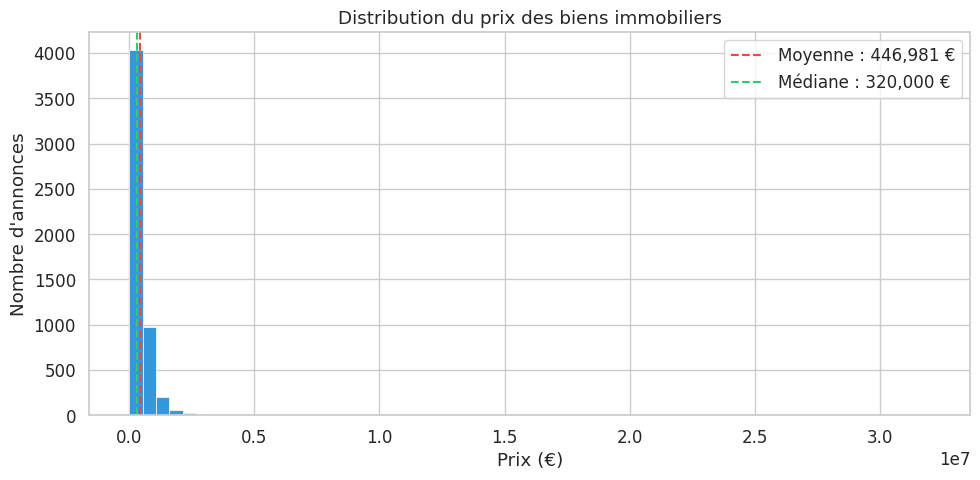

In [53]:
prix_pd = df.select('prix').dropna().toPandas()
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(prix_pd['prix'], bins=60, color='#3498db', edgecolor='white', linewidth=0.5)
mean_val = prix_pd['prix'].mean()
median_val = prix_pd['prix'].median()
ax.axvline(mean_val, color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Moyenne : {mean_val:,.0f} €')
ax.axvline(median_val, color='#2ecc71', linestyle='--', linewidth=1.5, label=f'Médiane : {median_val:,.0f} €')
ax.set_xlabel('Prix (€)')
ax.set_ylabel("Nombre d'annonces")
ax.set_title('Distribution du prix des biens immobiliers')
ax.legend()
plt.tight_layout()
plt.show()

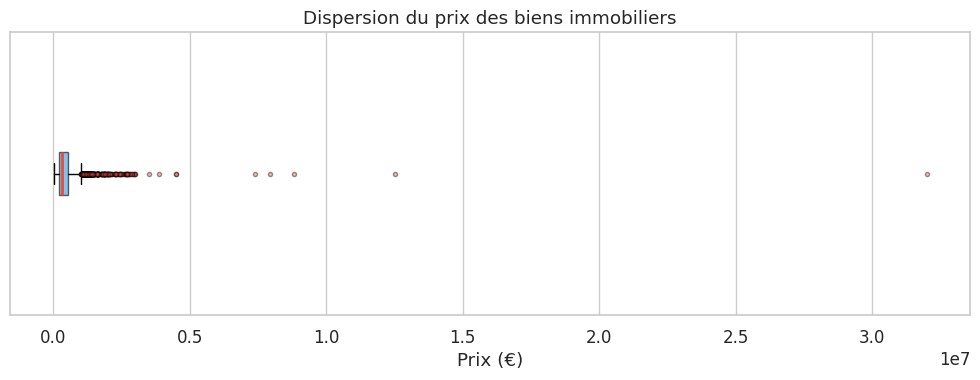

In [54]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot(prix_pd['prix'].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor='#3498db', alpha=0.6), medianprops=dict(color='#e74c3c', linewidth=2), flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=3, alpha=0.4))
ax.set_xlabel('Prix (€)')
ax.set_title('Dispersion du prix des biens immobiliers')
ax.yaxis.set_visible(False)
plt.tight_layout()
plt.show()

In [55]:
df_analyse = df.withColumn('tranche_surface', F.when(col('surface') < 30, '< 30m²').when(col('surface') < 50, '30-50m²').when(col('surface') < 80, '50-80m²').when(col('surface') < 120, '80-120m²').when(col('surface') < 200, '120-200m²').otherwise('> 200m²'))

df_analyse.groupBy('type_bien', 'tranche_surface').agg(F.count('prix').alias('nb_annonces'), F.round(F.median('prix'), 0).alias('prix_median'), F.round(F.mean('prix'), 0).alias('prix_moyen')).orderBy('type_bien', 'tranche_surface').show(50, truncate=False)

+-----------+---------------+-----------+-----------+----------+
|type_bien  |tranche_surface|nb_annonces|prix_median|prix_moyen|
+-----------+---------------+-----------+-----------+----------+
|appartement|120-200m²      |295        |700000.0   |998270.0  |
|appartement|30-50m²        |852        |197475.0   |245292.0  |
|appartement|50-80m²        |1561       |265000.0   |321829.0  |
|appartement|80-120m²       |967        |415000.0   |514626.0  |
|appartement|< 30m²         |267        |135000.0   |160332.0  |
|appartement|> 200m²        |39         |1190000.0  |2609874.0 |
|duplex     |120-200m²      |31         |745500.0   |873354.0  |
|duplex     |30-50m²        |23         |192000.0   |222889.0  |
|duplex     |50-80m²        |53         |287000.0   |351011.0  |
|duplex     |80-120m²       |69         |430000.0   |541384.0  |
|duplex     |< 30m²         |3          |238000.0   |250667.0  |
|duplex     |> 200m²        |5          |995000.0   |1729800.0 |
|immeuble   |120-200m²   

- La moyenne est de 446981 € , elle est beaucoup plus grande que la médiane. La majorité des biens a un prix situé entre 208 000 € et 530 000 €.
- Nous avons beaucoup d'incoherence sur les prix, on retire les biens avec une surface inférieure à 12 m², un prix inférieur à 80 000 € ou un prix au m² inférieur à 1 000 €.

In [56]:
df = df.withColumn("prix_m2", F.col("prix") / F.col("surface"))

df = df.filter(
    (F.col("surface") >= 12) &
    (F.col("prix") >= 80000) &
    (F.col("prix_m2") >= 1000)
)

## Analyse exploratoire - Variable nombres de chambres

In [57]:
total = df.count()
non_null = df.filter(F.col('nb_chambres').isNotNull()).count()
print(f"Total : {total} | Renseigné : {non_null} | Null : {total - non_null} ({(total - non_null)/total*100:.1f}%)")

Total : 5209 | Renseigné : 4695 | Null : 514 (9.9%)


In [58]:
df.groupBy('type_bien').agg(F.count('nb_chambres').alias('renseigné'), F.count('*').alias('total')).withColumn('taux_null_%', F.round((1 - F.col('renseigné')/F.col('total'))*100, 1)).orderBy(F.desc('total')).show(truncate=False)

+-----------+---------+-----+-----------+
|type_bien  |renseigné|total|taux_null_%|
+-----------+---------+-----+-----------+
|appartement|3639     |3932 |7.5        |
|maison     |778      |812  |4.2        |
|studio     |53       |218  |75.7       |
|duplex     |181      |184  |1.6        |
|loft       |38       |42   |9.5        |
|immeuble   |6        |21   |71.4       |
+-----------+---------+-----+-----------+



In [59]:
df.filter(F.col('nb_chambres').isNotNull()).groupBy('nb_chambres').count().orderBy('nb_chambres').show()

+-----------+-----+
|nb_chambres|count|
+-----------+-----+
|          1| 1279|
|          2| 1586|
|          3| 1137|
|          4|  468|
|          5|  162|
|          6|   45|
|          7|   16|
|          8|    1|
|         11|    1|
+-----------+-----+



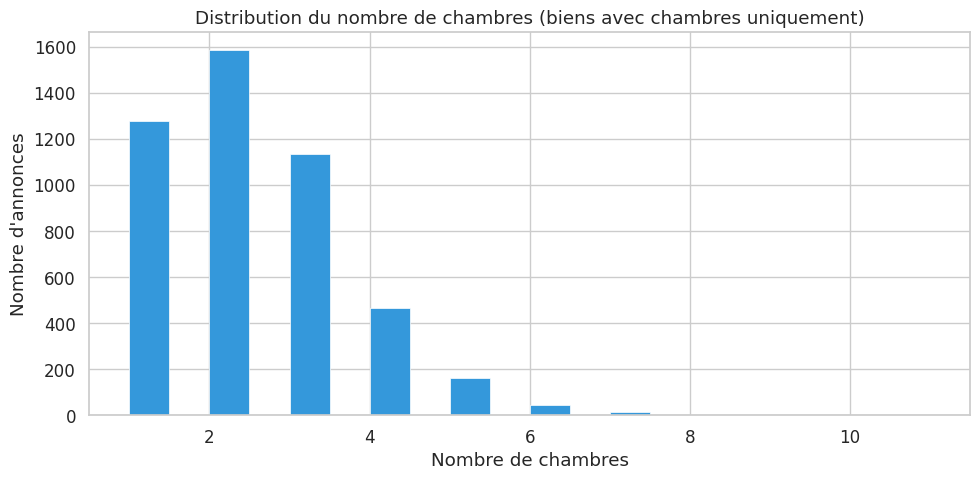

In [60]:
nb_chambres_pd = df.filter(F.col('nb_chambres').isNotNull()).select('nb_chambres').toPandas()
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(nb_chambres_pd['nb_chambres'], bins=20, color='#3498db', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Nombre de chambres')
ax.set_ylabel("Nombre d'annonces")
ax.set_title('Distribution du nombre de chambres (biens avec chambres uniquement)')
plt.tight_layout()
plt.show()

- La variable nombre de chambres est globalement cohérente. La majorité des biens ont entre 1 et 3 chambres, ce qui est logique. On observe environ 10 % de valeurs manquantes. 
- Ces valeurs nulles concernent surtout les studios et les immeubles, ce qui peut s’expliquer par la nature de ces biens. Les valeurs très élevées, comme 8 ou 11 chambres, sont très rares et devront être vérifiées.
- Pour le modèle, on remplace les valeurs manquantes par 0 pour les studios, puis on supprime les quelques lignes restantes où le nombre de chambres n’est pas renseigné.

In [61]:
avant_suppresion = df.count()
df = df.filter(F.col('nb_chambres').isNotNull())
print(f"Avant : {avant_suppresion} | Après : {df.count()} | Supprimées : {avant_suppresion- df.count()}")

Avant : 5209 | Après : 4695 | Supprimées : 514


In [62]:
df.groupBy('type_bien').agg(F.count('*').alias('total'), F.sum(F.when(F.col('nb_chambres').isNull(), 1).otherwise(0)).alias('nb_null')).orderBy(F.desc('nb_null')).show(truncate=False)

+-----------+-----+-------+
|type_bien  |total|nb_null|
+-----------+-----+-------+
|appartement|3639 |0      |
|duplex     |181  |0      |
|maison     |778  |0      |
|loft       |38   |0      |
|studio     |53   |0      |
|immeuble   |6    |0      |
+-----------+-----+-------+



## Preparation des features

In [63]:
df = df.withColumn('nb_pieces', F.col('nb_pieces').cast('double').cast('integer'))

In [64]:

TOP50_MOTS = ['appartement', 'situ', 'tage', 'maison', 'quartier', 'rue', 'immeuble', 'calme', 'chambres', 'terrasse', 'cuisine', 'salle', 'lumineux', 'ascenseur', 'balcon', 'jardin', 'saint', 'vie', 'proximit', 'jour', 'place', 'vue', 'exclusivit', 'dernier', 'parking', 'vendre', 'coeur', 'commerces', 'garage', 'proche', 'duplex', 'cave', 'recherch', 'studio', 'entr', 'eau', 'copropri', 'offre', 'rement', 'immobilier', 'nov', 'sejour', 'espace', 'beau', 'entier', 'calme', 'sud', 'expo', 'risques', 'geo']

for mot in TOP50_MOTS:
    df = df.withColumn('nlp_' + mot, F.when(F.lower(F.col('description')).contains(mot), 1.0).otherwise(0.0))

In [65]:
print(f'Colonnes NLP ajoutées : {len(TOP50_MOTS)}')
print(f'Total colonnes : {len(df.columns)}')

Colonnes NLP ajoutées : 50
Total colonnes : 61


## Pipeline 

In [66]:
indexer_ville = StringIndexer(inputCol='ville', outputCol='ville_index', handleInvalid='keep')
indexer_type  = StringIndexer(inputCol='type_bien', outputCol='type_index', handleInvalid='keep')
encoder_ville = OneHotEncoder(inputCol='ville_index', outputCol='ville_vecteur')
encoder_type  = OneHotEncoder(inputCol='type_index', outputCol='type_vecteur')

In [67]:
cols_nlp      = ['nlp_' + mot for mot in TOP50_MOTS]
cols_features = ['surface', 'nb_pieces', 'nb_chambres', 'ville_vecteur', 'type_vecteur'] + cols_nlp
assembler     = VectorAssembler(inputCols=cols_features, outputCol='features', handleInvalid='keep')

In [68]:
eval_rmse = RegressionEvaluator(labelCol='prix', predictionCol='prediction', metricName='rmse')
eval_mae  = RegressionEvaluator(labelCol='prix', predictionCol='prediction', metricName='mae')
eval_r2   = RegressionEvaluator(labelCol='prix', predictionCol='prediction', metricName='r2')

In [69]:
train, test = df.randomSplit([0.8, 0.2], seed=42)
print(f'Train : {train.count()} lignes | Test : {test.count()} lignes')
print(f'Nombre de features : {len(cols_features)}')

Train : 3815 lignes | Test : 880 lignes
Nombre de features : 55


# Régression 

## Entrainement des trois modeles de regression 